# Session 15 — Matplotlib: Bar Chart, Line Chart, Scatter Plot, Histogram
### Module 4: Data Cleaning, Visualization and EDA

This notebook covers:
- Introduction to matplotlib and the basic plotting workflow
- Bar charts — comparing categories
- Line charts — showing trends and change
- Scatter plots — showing relationships between two numeric variables
- Histograms — showing the distribution of a single numeric variable
- Customizing plots: titles, labels, colors, legends, subplots
- Hands-on practice exercises

We will use the **Tips dataset** from `seaborn` — real restaurant billing data with both numeric and categorical columns, well suited to all four chart types. This is a different dataset from wine, iris, titanic, and diamonds used in earlier sessions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the Dataset


In [2]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [29]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [3]:
df.shape

(244, 7)

In [47]:
df['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [48]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [49]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [50]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [46]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


**About the dataset:** each row is a restaurant bill. Columns include `total_bill`, `tip`, `sex`, `smoker`, `day`, `time` (Lunch/Dinner), and `size` (party size). This mix of numeric and categorical columns lets us demonstrate all four chart types meaningfully.


## 2. Introduction to Matplotlib

`matplotlib.pyplot` (usually imported as `plt`) is the foundational plotting library in Python. Most other visualization libraries, including `seaborn`, are built on top of it.

**Basic workflow for any plot:**
1. Create the plot: `plt.plot(...)`, `plt.bar(...)`, `plt.scatter(...)`, `plt.hist(...)`
2. Add labels/title: `plt.xlabel()`, `plt.ylabel()`, `plt.title()`
3. Optionally add a legend: `plt.legend()`
4. Display the plot: `plt.show()`


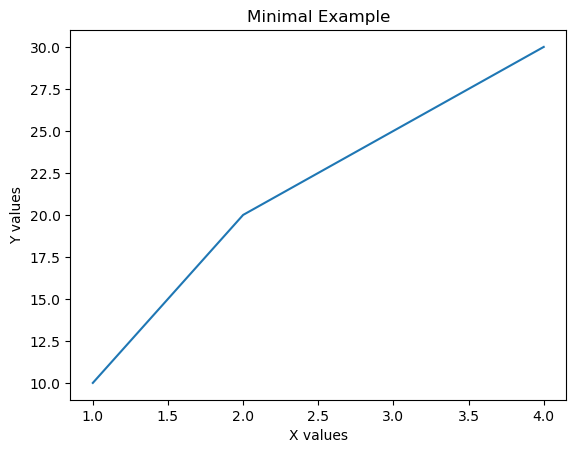

In [5]:
# A minimal example before working with real data
plt.plot([1, 2, 3, 4], [10, 20, 25, 30])
plt.title('Minimal Example')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()


## 3. Bar Chart

Bar charts are used to **compare values across categories**. Bar height (or length) represents the value of a numeric measure for each category.


In [6]:
# Average tip amount by day
avg_tip_by_day = df.groupby('day', observed=True)['tip'].mean()
avg_tip_by_day

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64

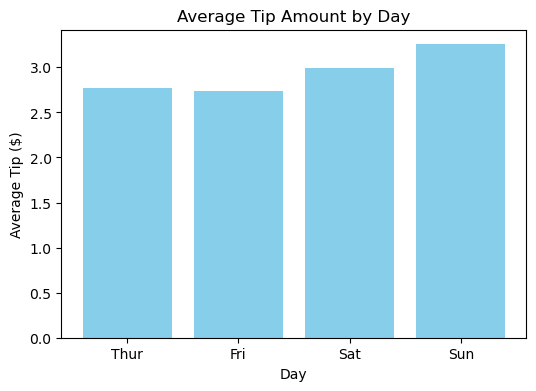

In [30]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a bar chart
# X-axis: Days (Thur, Fri, Sat, Sun)
# Y-axis: Average tip amount
# Bar color: Sky blue
plt.bar(avg_tip_by_day.index, avg_tip_by_day.values, color='skyblue')

# Add a title to the chart
plt.title('Average Tip Amount by Day')

# Label the X-axis
plt.xlabel('Day')

# Label the Y-axis
plt.ylabel('Average Tip ($)')

# Display the chart
plt.show()

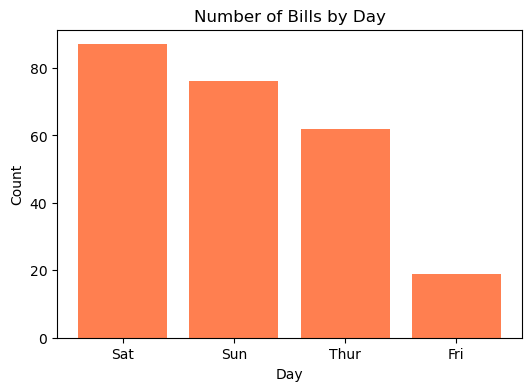

In [31]:
# Count the number of bills for each day
day_counts = df['day'].value_counts()

# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a bar chart
# X-axis: Days (categories)
# Y-axis: Number of bills (frequency/count)
# Bar color: Coral
plt.bar(day_counts.index, day_counts.values, color='coral')

# Add a title to the chart
plt.title('Number of Bills by Day')

# Label the X-axis
plt.xlabel('Day')

# Label the Y-axis
plt.ylabel('Count')

# Display the chart
plt.show()


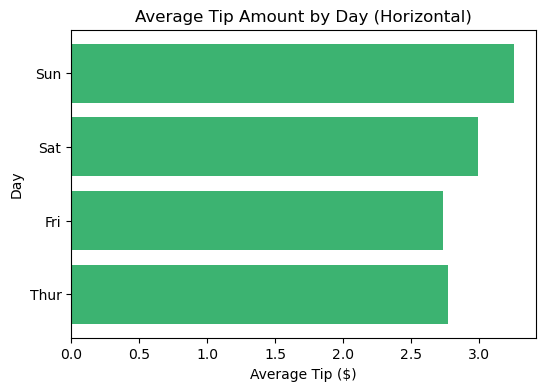

In [32]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a horizontal bar chart
# Y-axis: Days (categories)
# X-axis: Average tip amount
# Bar color: Medium sea green
plt.barh(avg_tip_by_day.index, avg_tip_by_day.values, color='mediumseagreen')

# Add a title to the chart
plt.title('Average Tip Amount by Day (Horizontal)')

# Label the X-axis
plt.xlabel('Average Tip ($)')

# Label the Y-axis
plt.ylabel('Day')

# Display the chart
plt.show()

In [33]:
# Group the data by 'day' and 'time' (Lunch/Dinner)
# Calculate the average total bill for each group
# Use unstack() to convert the 'time' groups into separate columns,
# making the data suitable for a grouped bar chart
grouped = df.groupby(['day', 'time'], observed=True)['total_bill'].mean().unstack()

# Display the grouped DataFrame
grouped

time,Lunch,Dinner
day,,
Thur,17.664754,18.780000
Fri,12.845714,19.663333
Sat,NaN,20.441379
Sun,NaN,21.410000


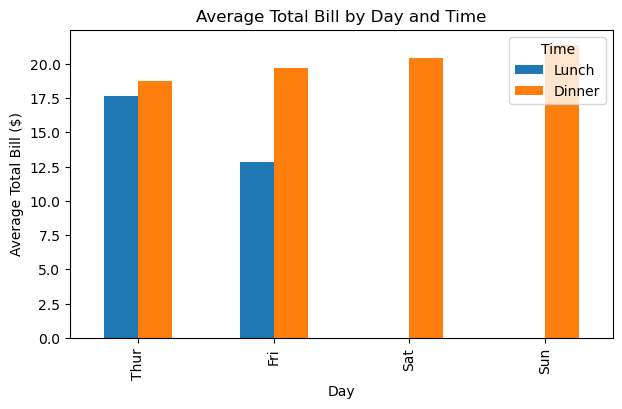

In [34]:
# Create a grouped bar chart from the grouped DataFrame
# Each day has separate bars for Lunch and Dinner
grouped.plot(kind='bar', figsize=(7, 4))

# Add a title to the chart
plt.title('Average Total Bill by Day and Time')

# Label the X-axis
plt.xlabel('Day')

# Label the Y-axis
plt.ylabel('Average Total Bill ($)')

# Add a legend to identify Lunch and Dinner bars
plt.legend(title='Time')

# Display the chart
plt.show()


## 4. Line Chart

Line charts are best suited for showing **trends or change over an ordered sequence**, typically time. Our dataset doesn't have a time series, so we'll first demonstrate the mechanics with a synthetic example, then apply the same idea to a meaningfully *ordered* category in our real data.


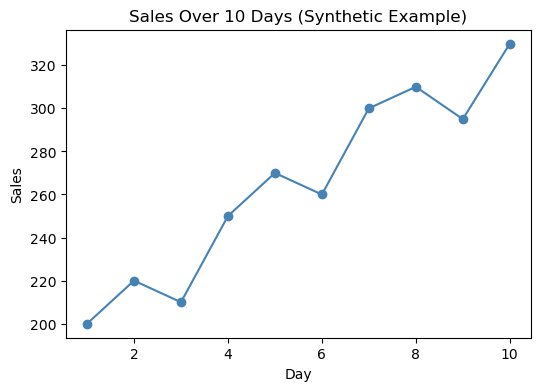

In [12]:
# Synthetic time series example -- to clearly show how a line chart works
days = np.arange(1, 11)
sales = [200, 220, 210, 250, 270, 260, 300, 310, 295, 330]

plt.figure(figsize=(6, 4))
plt.plot(days, sales, marker='o', color='steelblue')
plt.title('Sales Over 10 Days (Synthetic Example)')
plt.xlabel('Day')
plt.ylabel('Sales')
plt.show()


In [13]:
# Applying line charts to real data: average total_bill by party size (ordered, meaningful sequence)
avg_bill_by_size = df.groupby('size')['total_bill'].mean()
avg_bill_by_size

size
1     7.242500
2    16.448013
3    23.277632
4    28.613514
5    30.068000
6    34.830000
Name: total_bill, dtype: float64

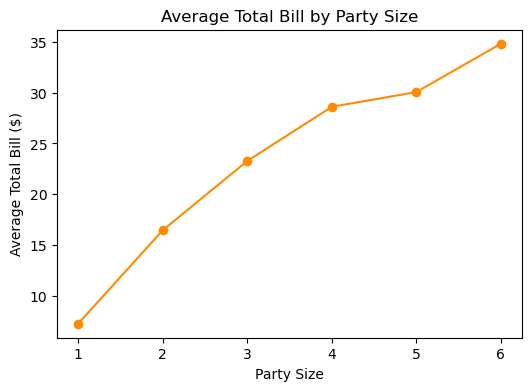

In [35]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a line chart
# X-axis: Party size
# Y-axis: Average total bill
# marker='o' displays a circle at each data point
# color='darkorange' sets the line color
plt.plot(avg_bill_by_size.index, avg_bill_by_size.values,
         marker='o', color='darkorange')

# Add a title to the chart
plt.title('Average Total Bill by Party Size')

# Label the X-axis
plt.xlabel('Party Size')

# Label the Y-axis
plt.ylabel('Average Total Bill ($)')

# Display all party size values as X-axis ticks
plt.xticks(avg_bill_by_size.index)

# Display the chart
plt.show()

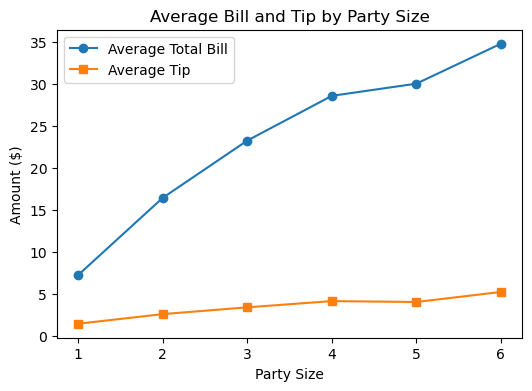

In [15]:
# Multiple lines on the same chart -- average total_bill AND average tip by party size
avg_by_size = df.groupby('size')[['total_bill', 'tip']].mean()

plt.figure(figsize=(6, 4))
plt.plot(avg_by_size.index, avg_by_size['total_bill'], marker='o', label='Average Total Bill')
plt.plot(avg_by_size.index, avg_by_size['tip'], marker='s', label='Average Tip')
plt.title('Average Bill and Tip by Party Size')
plt.xlabel('Party Size')
plt.ylabel('Amount ($)')
plt.legend()
plt.show()


In [51]:
avg_by_size

,total_bill,tip
size,,
1,7.242500,1.437500
2,16.448013,2.582308
3,23.277632,3.393158
4,28.613514,4.135405
5,30.068000,4.028000
6,34.830000,5.225000


## 5. Scatter Plot

Scatter plots show the **relationship between two numeric variables** — each point represents one observation (row).


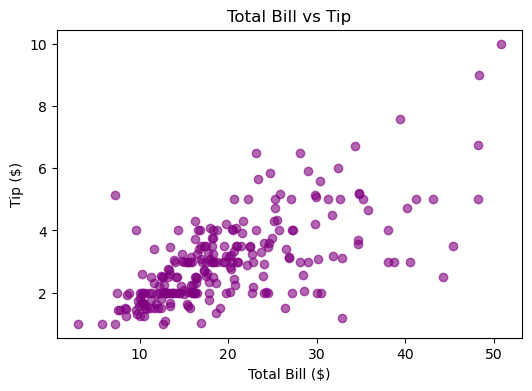

In [36]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a scatter plot
# X-axis: Total bill amount
# Y-axis: Tip amount
# alpha=0.6 makes the points slightly transparent
# color='purple' sets the point color
plt.scatter(df['total_bill'], df['tip'], alpha=0.6, color='purple')

# Add a title to the chart
plt.title('Total Bill vs Tip')

# Label the X-axis
plt.xlabel('Total Bill ($)')

# Label the Y-axis
plt.ylabel('Tip ($)')

# Display the chart
plt.show()


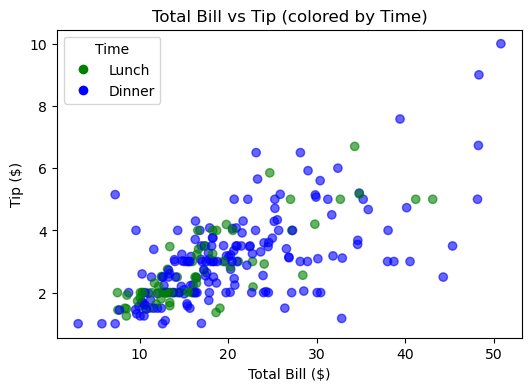

In [53]:
# Map each time category to a color
# Lunch -> Green, Dinner -> Blue
# This allows points to be colored based on the meal time
colors = df['time'].map({'Lunch': 'green', 'Dinner': 'blue'})

# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a scatter plot
# X-axis: Total bill amount
# Y-axis: Tip amount
# c=colors assigns a color to each point based on the 'time' column
# alpha=0.6 makes the points slightly transparent
plt.scatter(df['total_bill'], df['tip'], c=colors, alpha=0.6)

# Add a title to the chart
plt.title('Total Bill vs Tip (colored by Time)')

# Label the X-axis
plt.xlabel('Total Bill ($)')

# Label the Y-axis
plt.ylabel('Tip ($)')

# Import Line2D to create custom legend entries
from matplotlib.lines import Line2D

# Create custom legend items because plt.scatter() with c=colors
# does not automatically generate category labels
legend_elements = [
    # Green circle represents Lunch
    Line2D([0], [0], marker='o', color='w',
           label='Lunch', markerfacecolor='green', markersize=8),

    # Blue circle represents Dinner
    Line2D([0], [0], marker='o', color='w',
           label='Dinner', markerfacecolor='blue', markersize=8)
]

# Add the custom legend to the chart
plt.legend(handles=legend_elements, title='Time')

# Display the chart
plt.show()

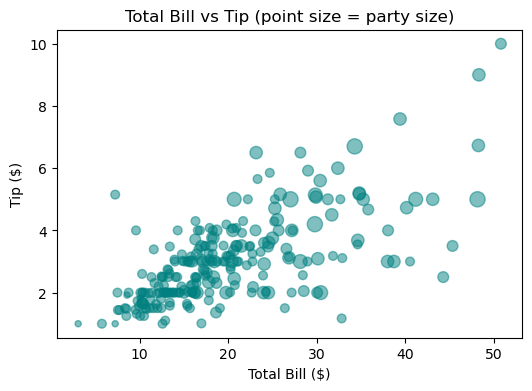

In [38]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a bubble chart (scatter plot)
# X-axis: Total bill amount
# Y-axis: Tip amount
# s=df['size'] * 20 sets the bubble size based on party size
# Multiplying by 20 makes the bubbles easier to see
# alpha=0.5 makes the bubbles slightly transparent
# color='teal' sets the bubble color
plt.scatter(df['total_bill'], df['tip'],
            s=df['size'] * 20,
            alpha=0.5,
            color='teal')

# Add a title to the chart
plt.title('Total Bill vs Tip (point size = party size)')

# Label the X-axis
plt.xlabel('Total Bill ($)')

# Label the Y-axis
plt.ylabel('Tip ($)')

# Display the chart
plt.show()


## 6. Histogram

Histograms show the **distribution/shape** of a single numeric column by grouping values into bins and counting how many fall in each bin.


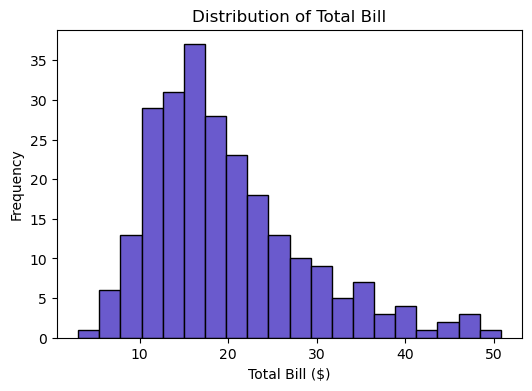

In [39]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a histogram
# Displays the distribution of total bill amounts
# bins=20 divides the data into 20 intervals (bins)
# color='slateblue' sets the bar color
# edgecolor='black' adds black borders to each bar
plt.hist(df['total_bill'], bins=20, color='slateblue', edgecolor='black')

# Add a title to the chart
plt.title('Distribution of Total Bill')

# Label the X-axis
plt.xlabel('Total Bill ($)')

# Label the Y-axis
plt.ylabel('Frequency')

# Display the chart
plt.show()


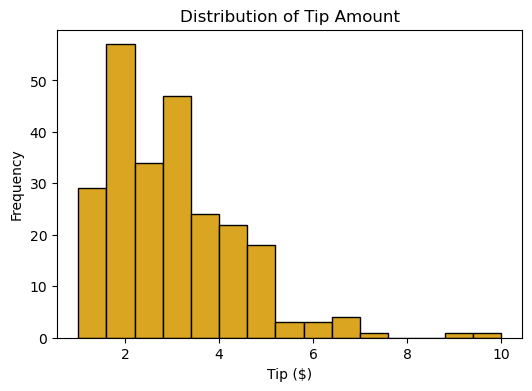

In [40]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a histogram
# Displays the distribution of tip amounts
# bins=15 divides the data into 15 intervals (bins)
# color='goldenrod' sets the bar color
# edgecolor='black' adds black borders to each bar
plt.hist(df['tip'], bins=15, color='goldenrod', edgecolor='black')

# Add a title to the chart
plt.title('Distribution of Tip Amount')

# Label the X-axis
plt.xlabel('Tip ($)')

# Label the Y-axis
plt.ylabel('Frequency')

# Display the chart
plt.show()


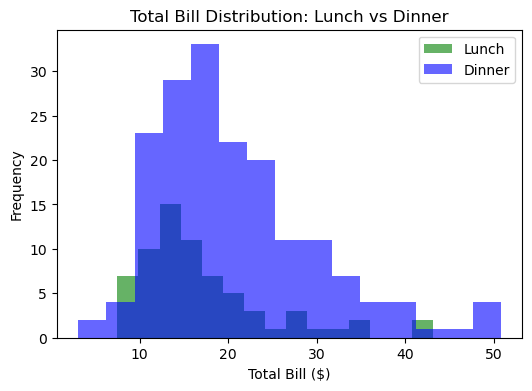

In [41]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a histogram for Lunch total bill amounts
# Select only Lunch records
# bins=15 divides the data into 15 intervals
# alpha=0.6 makes the bars slightly transparent
# label='Lunch' is used in the legend
# color='green' sets the bar color
plt.hist(df[df['time'] == 'Lunch']['total_bill'],
         bins=15,
         alpha=0.6,
         label='Lunch',
         color='green')

# Create a histogram for Dinner total bill amounts
# Select only Dinner records
# Uses the same bins so both distributions can be compared
plt.hist(df[df['time'] == 'Dinner']['total_bill'],
         bins=15,
         alpha=0.6,
         label='Dinner',
         color='blue')

# Add a title to the chart
plt.title('Total Bill Distribution: Lunch vs Dinner')

# Label the X-axis
plt.xlabel('Total Bill ($)')

# Label the Y-axis
plt.ylabel('Frequency')

# Display the legend to identify Lunch and Dinner histograms
plt.legend()

# Display the chart
plt.show()


## 7. Customizing Plots

A few essential customizations that make charts clearer and more professional.


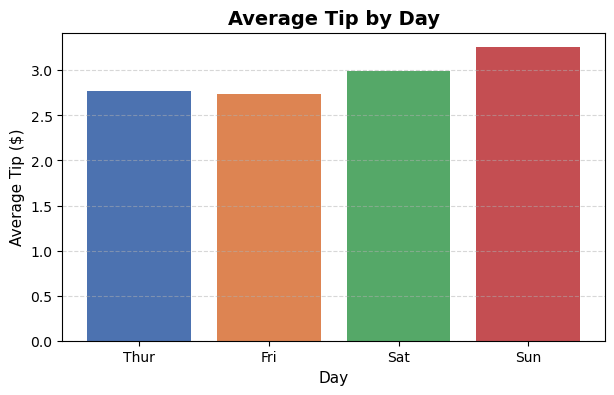

In [42]:
# Create a new figure with width = 7 inches and height = 4 inches
plt.figure(figsize=(7, 4))

# Create a bar chart
# X-axis: Days of the week
# Y-axis: Average tip amount
# color assigns a different color to each bar
plt.bar(avg_tip_by_day.index,
        avg_tip_by_day.values,
        color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])

# Add a chart title
# fontsize=14 increases the title size
# fontweight='bold' makes the title bold
plt.title('Average Tip by Day', fontsize=14, fontweight='bold')

# Label the X-axis
# fontsize=11 sets the label size
plt.xlabel('Day', fontsize=11)

# Label the Y-axis
# fontsize=11 sets the label size
plt.ylabel('Average Tip ($)', fontsize=11)

# Add horizontal grid lines for easier comparison
# axis='y' displays grid lines only on the Y-axis
# linestyle='--' uses dashed lines
# alpha=0.5 makes the grid lines slightly transparent
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the chart
plt.show()


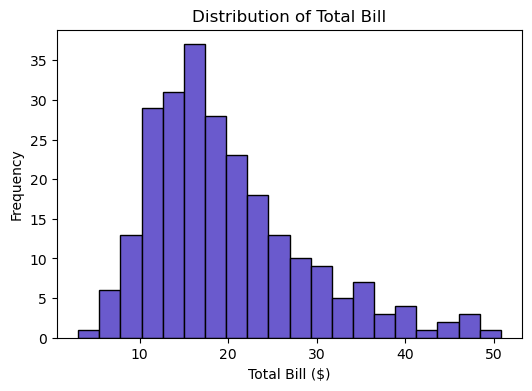

Saved as total_bill_histogram.png


In [43]:
# Create a new figure with width = 6 inches and height = 4 inches
plt.figure(figsize=(6, 4))

# Create a histogram
# Displays the distribution of total bill amounts
# bins=20 divides the data into 20 intervals
# color='slateblue' sets the bar color
# edgecolor='black' adds black borders to each bar
plt.hist(df['total_bill'], bins=20, color='slateblue', edgecolor='black')

# Add a title to the chart
plt.title('Distribution of Total Bill')

# Label the X-axis
plt.xlabel('Total Bill ($)')

# Label the Y-axis
plt.ylabel('Frequency')

# Save the current figure as an image file
# 'total_bill_histogram.png' is the file name
# dpi=150 increases the image quality (resolution)
# bbox_inches='tight' removes extra white space around the figure
plt.savefig('total_bill_histogram.png', dpi=150, bbox_inches='tight')

# Display the chart
plt.show()

# Print a confirmation message after saving the image
print("Saved as total_bill_histogram.png")

## 8. Subplots — Combining Multiple Charts in One Figure

`plt.subplots()` lets you place several charts side by side or in a grid — very useful for a quick multi-view EDA summary.


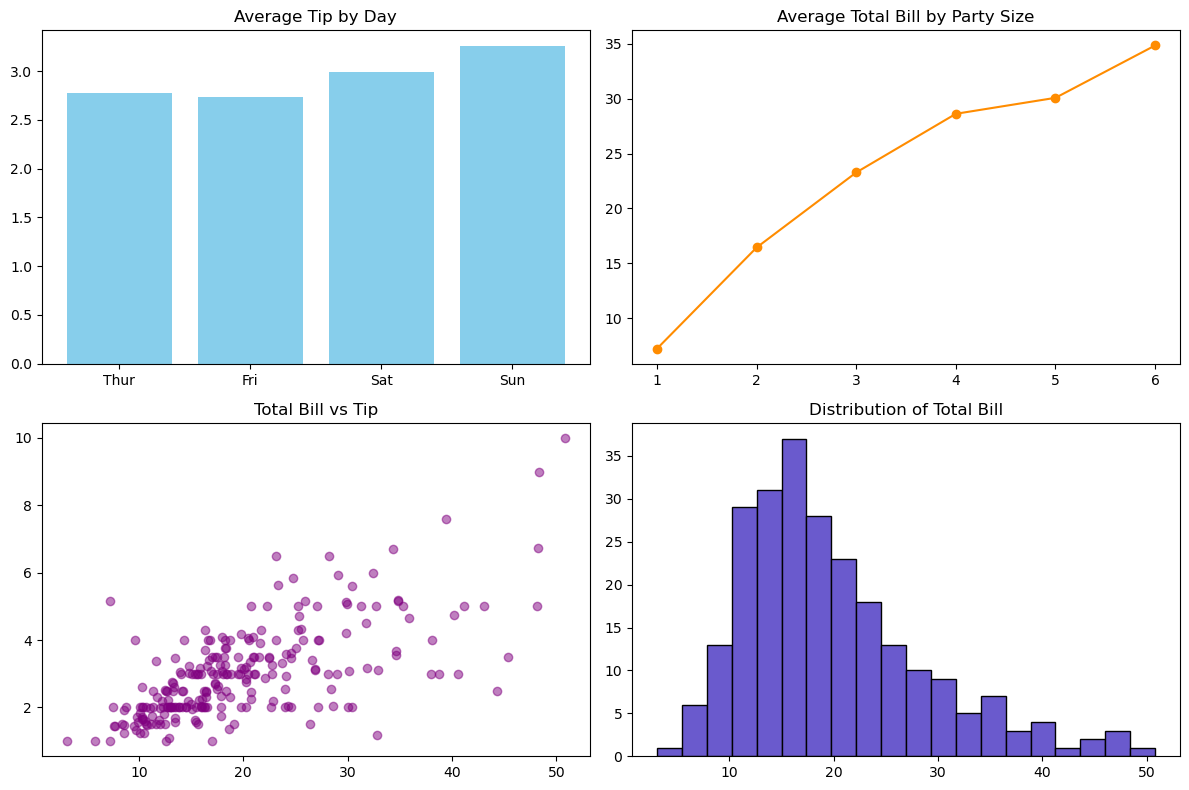

In [44]:
# Create a figure with a 2x2 grid of subplots
# figsize=(12, 8) sets the overall figure size
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# -------------------- Bar Chart --------------------

# Create a bar chart in the first subplot (top-left)
# axes[0, 0] refers to row 0, column 0
axes[0, 0].bar(avg_tip_by_day.index,
               avg_tip_by_day.values,
               color='skyblue')

# Add a title to the bar chart
axes[0, 0].set_title('Average Tip by Day')

# -------------------- Line Chart --------------------

# Create a line chart in the second subplot (top-right)
# marker='o' displays a circle at each data point
axes[0, 1].plot(avg_bill_by_size.index,
                avg_bill_by_size.values,
                marker='o',
                color='darkorange')

# Add a title to the line chart
axes[0, 1].set_title('Average Total Bill by Party Size')

# -------------------- Scatter Plot --------------------

# Create a scatter plot in the third subplot (bottom-left)
# alpha=0.5 makes the points slightly transparent
axes[1, 0].scatter(df['total_bill'],
                   df['tip'],
                   alpha=0.5,
                   color='purple')

# Add a title to the scatter plot
axes[1, 0].set_title('Total Bill vs Tip')

# -------------------- Histogram --------------------

# Create a histogram in the fourth subplot (bottom-right)
# bins=20 divides the data into 20 intervals
# edgecolor='black' adds borders to the bars
axes[1, 1].hist(df['total_bill'],
                bins=20,
                color='slateblue',
                edgecolor='black')

# Add a title to the histogram
axes[1, 1].set_title('Distribution of Total Bill')

# Automatically adjust spacing between all subplots
# Prevents titles and labels from overlapping
plt.tight_layout()

# Display all four charts together
plt.show()

## 9. Choosing the Right Chart — Quick Reference

| Chart Type | Best For | Example from Today |
|---|---|---|
| Bar Chart | Comparing values across categories | Average tip by day |
| Line Chart | Showing trend/change over an ordered sequence | Average bill by party size |
| Scatter Plot | Relationship between two numeric variables | Total bill vs tip |
| Histogram | Distribution/shape of one numeric variable | Distribution of total bill |


## 10. Hands-on Practice Exercise 1 — Bar Chart

Using the `tips` dataset:

1. Create a bar chart of the average `total_bill` for smokers vs non-smokers
2. Create a bar chart showing the count of bills by `time` (Lunch vs Dinner)
3. Add proper title, x-label, and y-label to both charts
4. Create a grouped bar chart of average `tip` by `day`, split by `sex`


In [25]:
# Write your solution here



## 11. Hands-on Practice Exercise 2 — Line Chart

1. Create a line chart of average `tip` by `size` (party size)
2. Add markers to the line and a grid
3. Plot both average `total_bill` and average `tip` by `size` on the same chart with a legend


In [26]:
# Write your solution here



## 12. Hands-on Practice Exercise 3 — Scatter Plot and Histogram

1. Create a scatter plot of `size` (party size) vs `total_bill`
2. Color the scatter plot points by `smoker` status, with a legend
3. Create a histogram of the `tip` column with 25 bins
4. Create overlapping histograms comparing `tip` amounts for smokers vs non-smokers


In [27]:
# Write your solution here



## 13. Hands-on Practice Exercise 4 — Combined Dashboard

1. Using `plt.subplots()`, create a 2x2 grid of charts:
   - Bar chart: average total_bill by day
   - Line chart: average tip by size
   - Scatter plot: total_bill vs tip, colored by time
   - Histogram: distribution of size
2. Give each subplot a title
3. Save the final combined figure as a PNG file


In [28]:
# Write your solution here



## Key Terms Glossary

| Term | Meaning |
|---|---|
| `plt.bar()` / `plt.barh()` | Vertical / horizontal bar chart |
| `plt.plot()` | Line chart |
| `plt.scatter()` | Scatter plot |
| `plt.hist()` | Histogram |
| `plt.title()` / `xlabel()` / `ylabel()` | Chart labeling |
| `plt.legend()` | Adds a legend to distinguish series/categories |
| `plt.figure(figsize=...)` | Sets the size of the chart |
| `plt.subplots()` | Creates a grid of multiple charts in one figure |
| `plt.savefig()` | Saves the chart to an image file |
| `bins` | Number of intervals a histogram divides the data range into |
| `alpha` | Transparency level of plot elements |


## Common Mistakes to Avoid

- Using a line chart on unordered categorical data — line charts imply a sequence/order, so use a bar chart instead
- Forgetting `plt.show()` at the end of a plotting cell (in some environments plots may not render without it)
- Not labeling axes or adding a title, making the chart hard to interpret
- Choosing too few or too many histogram bins, which can hide or exaggerate the shape of the distribution
- Using `plt.scatter(..., c=colors)` without manually building a legend, since it doesn't auto-generate one the way categorical bar/line plots do
- Overlapping bar charts without adjusting width/position, making bars hide each other instead of appearing grouped


## Homework / Practice Assignment

1. Pick any dataset (can be `sns.load_dataset('penguins')`, `sns.load_dataset('titanic')`, or your own CSV file)
2. Create one bar chart, one line chart, one scatter plot, and one histogram from it, each with proper titles and axis labels
3. Combine all four into a single 2x2 subplot dashboard
4. Save the final dashboard as a PNG file
5. Come prepared with 2 questions/doubts for the next session on EDA summary writing and chart interpretation
